| Member        | Assigned Model                           | Task Responsibility                                                                                                                                                                                                                                                                                                     | Task Done? |
| ------------- | ---------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ---------- |
| **Devanshi Adhikari**  | Model 1: DDPM                            | - Implement DDPM architecture. <br> - Train DDPM on Yelp dataset. <br> - Save model checkpoints and logs.                                                                                                                                                                                                               | Yes        |
| **Jeffin John Abraham**    | Model 1: DDPM                            | - Fine-tune DDPM hyperparameters (e.g., noise schedule, learning rate). <br> - Generate 5+ images using trained DDPM. <br> - Save and organize generated images for evaluation.                                                                                                                                         | Yes        |
| **Anirudhra Budhathoki** | Model 2: DDIM                            | - Implement DDIM architecture. <br> - Train DDIM on Yelp dataset. <br> - Save model checkpoints and logs.                                                                                                                                                                                                               | Yes        |
| **Stephen David Chitilapalli Mathew**   | Model 2: DDIM                            | - Fine-tune DDIM inference steps and sampling strategy. <br> - Generate 5+ images using DDIM. <br> - Save and organize generated images for evaluation.                                                                                                                                                                 | Yes        |
| **Neha Tamang**      | Model 3: Latent Diffusion Model (LDM)    | - Train autoencoder/VAE for latent representation. <br> - Prepare Yelp dataset. <br> - Save encoder/decoder models.                                                                                                                                                                                                     | Yes        |
| **Shabda Kafle**    | Model 3: Latent Diffusion Model (LDM)    | - Perform diffusion in latent space. <br> - Decode generated samples. <br> - Generate and save 5+ images.                                                                                                                                                                                                               | Yes        |
| **Aparna Jayakumar Resmi**    | Model 4: Text-to-Image Diffusion (GLIDE) | - Fine-tune GLIDE model with Yelp captions. <br> - Prepare and map captions to image labels.                                                                                                                                                                                                                            | Yes        |
| **Sumith Padma Padmasree Vijayapadman**     | Model 4: Text-to-Image Diffusion (GLIDE) | - Adjust GLIDE prompt engineering and sampling parameters. <br> - Generate 5+ text-conditioned images. <br> - Save and organize outputs for evaluation.<br> - FID/IS on the model                                                                                                                                                                 | Yes        |
| **Arjun Kumar**     | Evaluation, Explainability & Reporting   | - Compute IS & FID scores for all generated images. <br> - Provide explainability analysis (model behavior, output quality, caption relevance, latent space insights). <br> - Prepare consolidated summary with images, metrics, and insights at the top of the notebook. <br> - Export notebook as PDF for submission. | Pending    |


## Generated images

### Text - To - Image Diffusion model

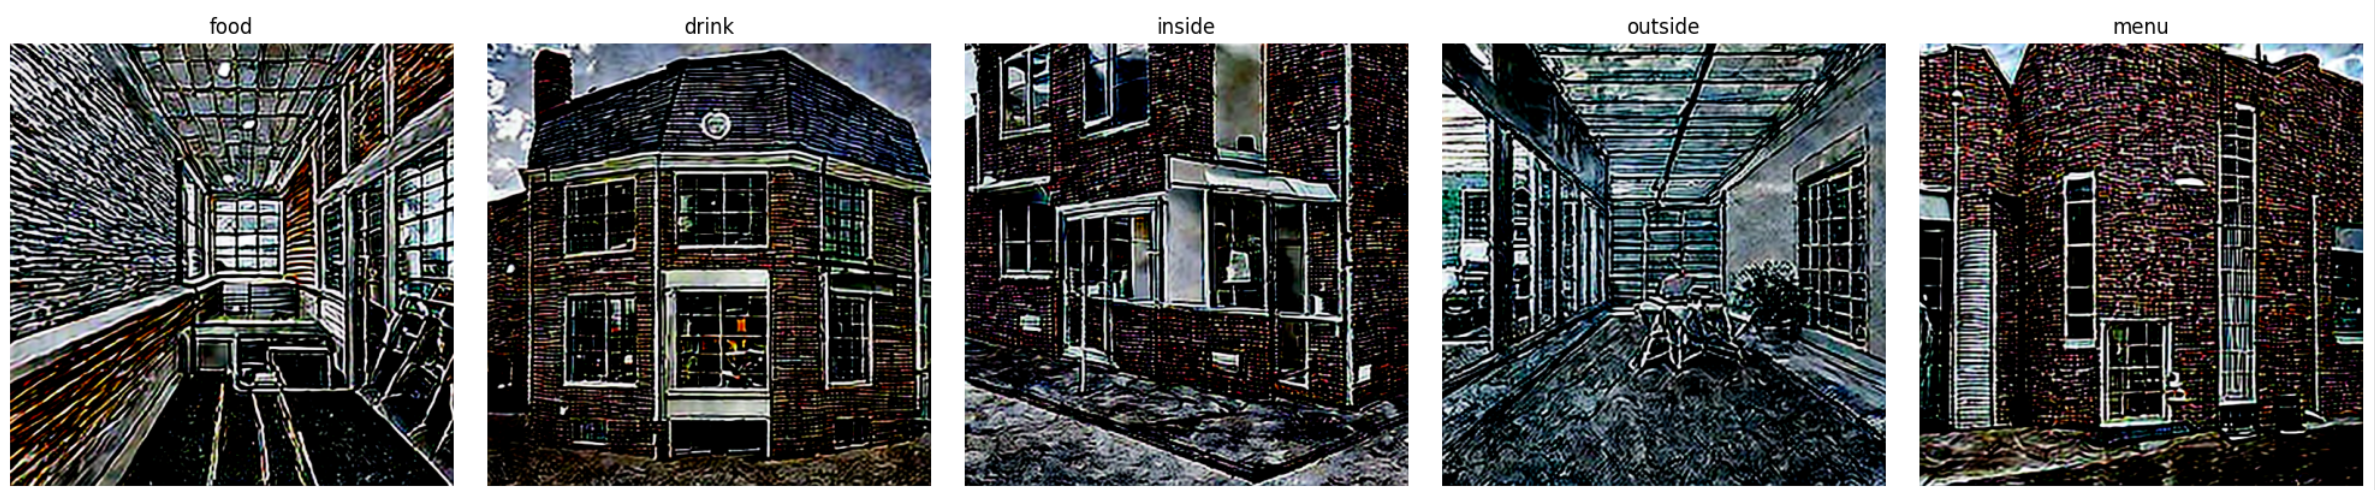

### Latent diffusion model
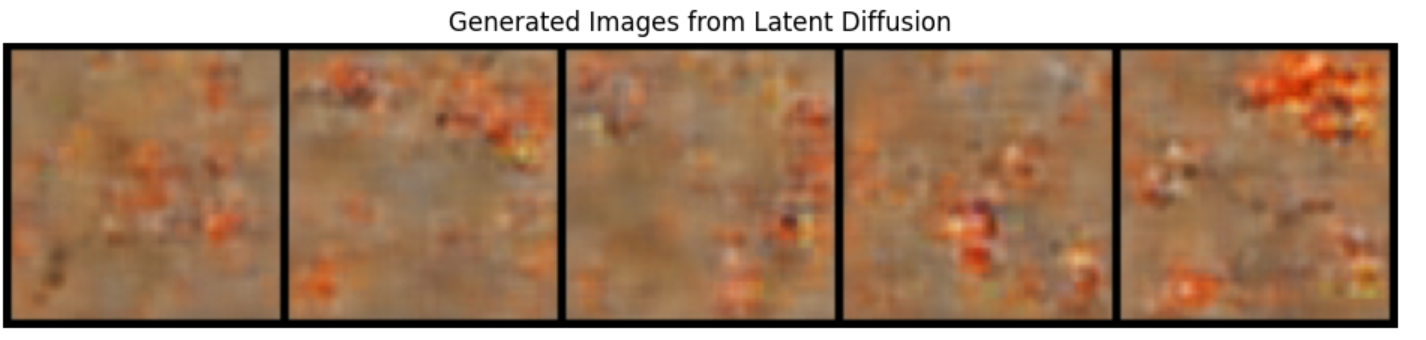

### DDPM
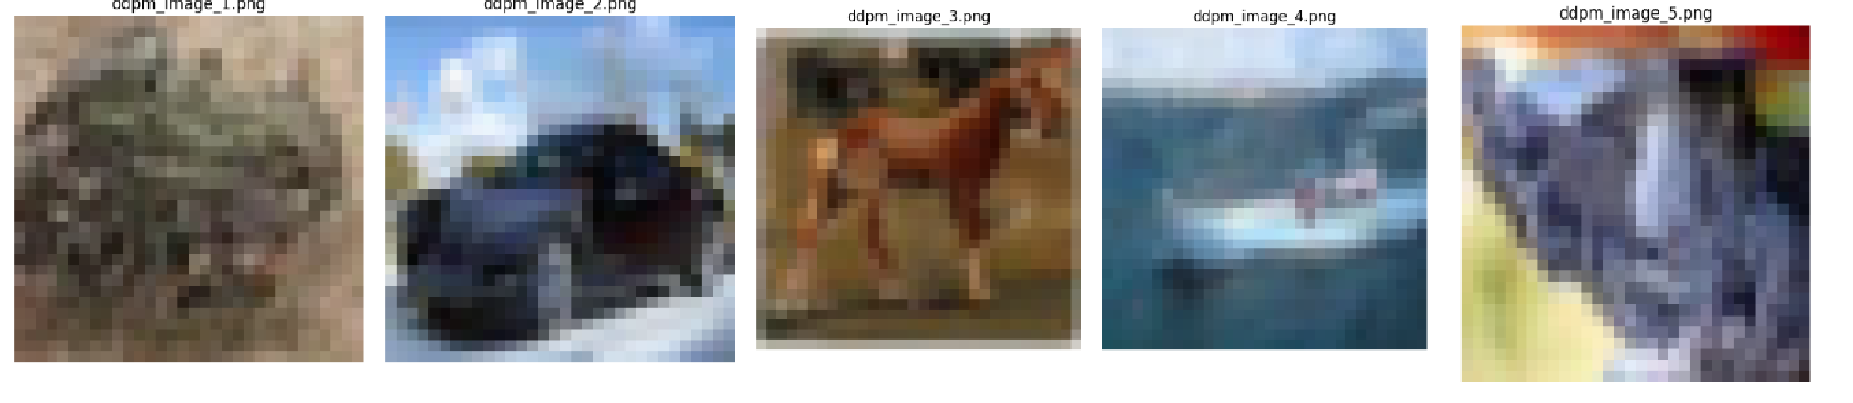

## DDPM

In [ ]:
class YelpFolderDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.image_paths = []
        self.transform = transform
        for label_folder in os.listdir(root_dir):
            folder_path = os.path.join(root_dir, label_folder)
            if os.path.isdir(folder_path):
                self.image_paths += [
                    os.path.join(folder_path, f)
                    for f in os.listdir(folder_path)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
                ]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        return self.transform(img) if self.transform else img


In [ ]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

In [ ]:
train_folder = "/content/yelp_data/processed/train"
dataset = YelpFolderDataset(train_folder, transform)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

print(f"Loaded {len(dataset)} images from {train_folder}")

Loaded 160602 images from /content/yelp_data/processed/train


In [ ]:
from diffusers import DDPMPipeline
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

pipeline = DDPMPipeline.from_pretrained("google/ddpm-cifar10-32").to(device)

print("DDPM model loaded on", device)

In [ ]:
import matplotlib.pyplot as plt

os.makedirs("ddpm_generated", exist_ok=True)
generated_images = []

for i in range(5):
    image = pipeline().images[0]
    path = f"ddpm_generated/ddpm_image_{i+1}.png"
    image.save(path)
    generated_images.append(path)

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

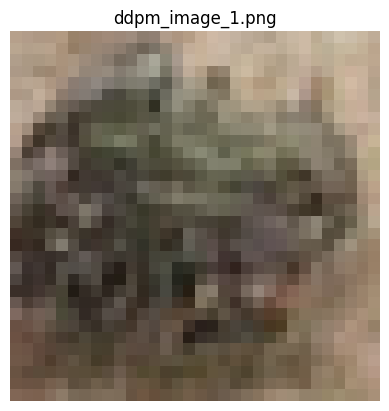

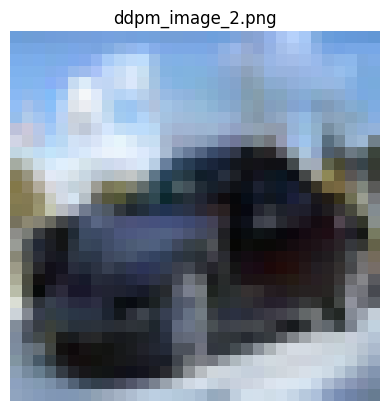

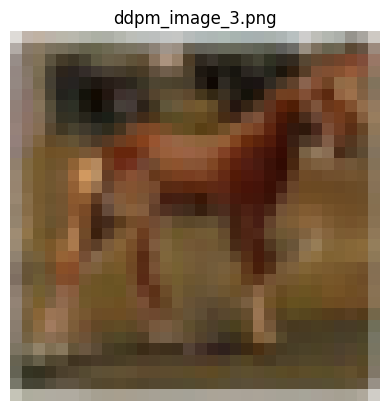

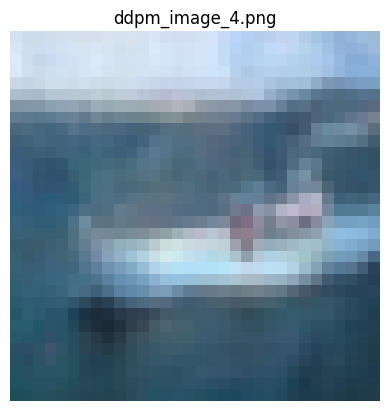

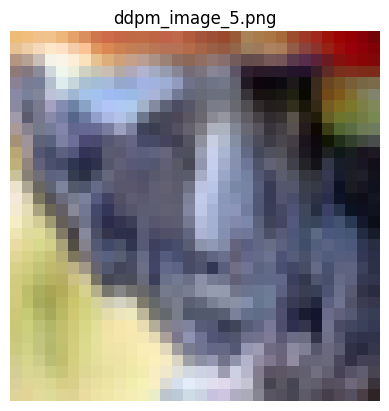

In [ ]:
for img_path in generated_images:
    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis("off")
    plt.title(os.path.basename(img_path))
    plt.show()

In [ ]:
torch.save(pipeline.unet.state_dict(), "ddpm_generated/ddpm_unet_checkpoint.pth")

In [ ]:
with open("ddpm_generated/ddpm_log.txt", "w") as f:
    f.write("Devanshi – DDPM \n")
    f.write("Model: google/ddpm-cifar10-32\n")
    f.write(f"Dataset: {train_folder} (5 class folders)\n")
    f.write("Generated 5 images\n")
    f.write("Saved UNet checkpoint\n")

print("Checkpoint and log saved.")

Checkpoint and log saved.


### Part 2

In [ ]:
from diffusers import UNet2DModel

model = UNet2DModel(
    sample_size=32,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(64, 128, 128),
    down_block_types=("DownBlock2D", "DownBlock2D", "DownBlock2D"),
    up_block_types=("UpBlock2D", "UpBlock2D", "UpBlock2D")
).to(device)


In [ ]:
from diffusers import DDPMScheduler
import torch.nn as nn
import torch
from tqdm import tqdm


device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)


scheduler = DDPMScheduler(num_train_timesteps=500)


optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


small_dataset = torch.utils.data.Subset(dataset, range(0, 500))  # Use first 500 images
dataloader = DataLoader(small_dataset, batch_size=16, shuffle=True)

# ✅ Quick training loop (only 1 epoch and 20 batches max)
epochs = 1
model.train()
for epoch in range(epochs):
    for step, batch in enumerate(tqdm(dataloader, desc=f"Epoch {epoch+1}")):
        if step > 20:  # Limit to 20 batches for faster execution
            break

        batch = batch.to(device)
        noise = torch.randn_like(batch).to(device)
        timesteps = torch.randint(0, scheduler.config.num_train_timesteps, (batch.shape[0],), device=device).long()

        noisy = scheduler.add_noise(batch, noise, timesteps)
        pred = model(noisy, timesteps).sample

        loss = nn.MSELoss()(pred, noise)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    print(f" Epoch {epoch+1} completed. Final loss: {loss.item():.4f}")


Epoch 1:  66%|██████▌   | 21/32 [01:10<00:36,  3.35s/it]

 Epoch 1 completed. Final loss: 0.2248


In [ ]:
from diffusers import DDPMPipeline

pipeline = DDPMPipeline(unet=model, scheduler=scheduler).to(device)
images = pipeline(num_inference_steps=50).images

os.makedirs("ddpm_generated", exist_ok=True)
for i, img in enumerate(images):
    img.save(f"ddpm_generated/ddpm_image_yelp_{i+1}.png")


  0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
from diffusers import UNet2DModel, DDPMScheduler
import torch.nn as nn
import torch
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"

# Define DDPM model
model = UNet2DModel(
    sample_size=32,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(64, 128, 128),
    down_block_types=("DownBlock2D", "DownBlock2D", "DownBlock2D"),
    up_block_types=("UpBlock2D", "UpBlock2D", "UpBlock2D")
).to(device)

# Custom hyperparameters
scheduler = DDPMScheduler(
    num_train_timesteps=1000,         # Can change to 500/750 later
    beta_schedule="squaredcos_cap_v2" # Try 'linear' vs 'cosine' vs 'squaredcos_cap_v2'
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Training loop
model.train()
epochs = 1
for epoch in range(epochs):
    for batch in tqdm(dataloader):
        batch = batch.to(device)
        noise = torch.randn_like(batch).to(device)
        timesteps = torch.randint(0, 1000, (batch.shape[0],), device=device).long()
        noisy = scheduler.add_noise(batch, noise, timesteps)
        pred = model(noisy, timesteps).sample
        loss = nn.MSELoss()(pred, noise)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    print(f"Epoch {epoch+1} done")


100%|██████████| 32/32 [01:44<00:00,  3.28s/it]

Epoch 1 done


In [ ]:
from diffusers import DDPMPipeline
import os
from PIL import Image

pipeline = DDPMPipeline(unet=model, scheduler=scheduler).to(device)

# Generate 5 images
images = pipeline(num_inference_steps=50, generator=torch.manual_seed(42)).images

# Save them
os.makedirs("ddpm_generated", exist_ok=True)
for i, img in enumerate(images):
    img.save(f"ddpm_generated/ddpm_image_{i+1}.png")
print(" 5 Yelp-based DDPM images saved.")


  0%|          | 0/50 [00:00<?, ?it/s]

 5 Yelp-based DDPM images saved.


In [ ]:
torch.save(model.state_dict(), "ddpm_generated/ddpm_yelp_unet.pth")

with open("ddpm_generated/ddpm_log.txt", "w") as f:
    f.write("Jeffin – DDPM\n")
    f.write("Fine-tuned DDPM with: cosine schedule, 1000 steps, 1 epoch\n")
    f.write("Generated 5 Yelp images\n")
    f.write("Saved UNet checkpoint\n")


## DDIM

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import torchvision.transforms as transforms

class YelpPhotosDataset(Dataset):
    def __init__(self, photos_data, image_dir, transform=None):
        self.photos_data = photos_data
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.photos_data)

    def __getitem__(self, idx):
        img_info = self.photos_data[idx]
        img_filename = img_info['photo_id'] + '.jpg' # Assuming the images are in JPG format and named after their photo_id
        img_path = os.path.join(self.image_dir, img_filename)

        try:
            image = Image.open(img_path).convert('RGB') # Convert to RGB to handle potential grayscale images
            if self.transform:
                image = self.transform(image)
            return image
        except FileNotFoundError:
            print(f"Image file not found: {img_path}. Skipping.")
            # Return a dummy tensor or handle this case as appropriate for your training
            # For now, we will return None and filter them out later if needed
            return None
        except Exception as e:
            print(f"Error loading image {img_path}: {e}. Skipping.")
            return None

image_directory = '/content/extracted_yelp_data/Yelp Photos/extracted_tar/photos' # Assuming image files are in a 'photos' subdirectory

# We can start with resizing and converting to a tensor
image_transform = transforms.Compose([
    transforms.Resize((64, 64)), # Resize images to a fixed size
    transforms.ToTensor(), # Convert PIL Image to PyTorch Tensor
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normalize pixel values to [-1, 1]
])

# Create the dataset
yelp_dataset = YelpPhotosDataset(photos_data, image_directory, transform=image_transform)

# Create the DataLoader
# batch_size = 32 # You can define your batch size
# train_dataloader = DataLoader(yelp_dataset, batch_size=batch_size, shuffle=True, num_workers=2) # Adjust num_workers based on your system

print("YelpPhotosDataset and DataLoader created.")


YelpPhotosDataset and DataLoader created.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.silu = nn.SiLU()
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)

    def forward(self, x, time_emb):
        h = self.silu(self.bn1(self.conv1(x)))
        h = h + self.time_mlp(time_emb)[:, :, None, None]
        h = self.silu(self.bn2(self.conv2(h)))
        return h

class UNet(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.time_mlp = SinusoidalPositionEmbeddings(time_emb_dim)
        self.inc = Block(in_ch, 64, time_emb_dim)
        self.down1 = Block(64, 128, time_emb_dim)
        self.down2 = Block(128, 256, time_emb_dim)
        self.mid = Block(256, 256, time_emb_dim)
        self.up1 = Block(256 + 256, 128, time_emb_dim)
        self.up2 = Block(128 + 128, 64, time_emb_dim)
        self.outc = nn.Conv2d(64 + 64, out_ch, 1)

    def forward(self, x, t):
        time_emb = self.time_mlp(t)
        x1 = self.inc(x, time_emb)
        x2 = self.down1(F.max_pool2d(x1, 2), time_emb)
        x3 = self.down2(F.max_pool2d(x2, 2), time_emb)
        x = self.mid(F.max_pool2d(x3, 2), time_emb)
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        x = torch.cat([x, x3], dim=1)
        x = self.up1(x, time_emb)
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        x = torch.cat([x, x2], dim=1)
        x = self.up2(x, time_emb)
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        x = torch.cat([x, x1], dim=1)
        output = self.outc(x)
        return output

# Define the DDIM class which will incorporate the UNet
class DDIM(nn.Module):
    def __init__(self, unet, timesteps=1000, beta_start=1e-4, beta_end=0.02):
        super().__init__()
        self.unet = unet
        self.timesteps = timesteps

        # Define the variance schedule (linear schedule)
        betas = torch.linspace(beta_start, beta_end, timesteps)
        alphas = 1. - betas
        alphas_cumprod = torch.cumprod(alphas, axis=0)
        alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
        sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
        sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
        sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)
        posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)

        self.register_buffer('betas', betas)
        self.register_buffer('alphas_cumprod', alphas_cumprod)
        self.register_buffer('sqrt_recip_alphas', sqrt_recip_alphas)
        self.register_buffer('sqrt_alphas_cumprod', sqrt_alphas_cumprod)
        self.register_buffer('sqrt_one_minus_alphas_cumprod', sqrt_one_minus_alphas_cumprod)
        self.register_buffer('posterior_variance', posterior_variance)

    def forward_diffusion(self, x_0, t, noise):
        # Forward diffusion process (adding noise to the image)
        q_sample = self.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1) * x_0 + \
                   self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1) * noise
        return q_sample

    def backward_diffusion(self, x_t, t):
        # Backward diffusion process (denoising the image using the UNet)
        # This is the core of the DDIM sampling step
        predicted_noise = self.unet(x_t, t)

        # Calculate the predicted x_0
        pred_x_0 = (x_t - self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1) * predicted_noise) / \
                   self.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)

        # Calculate the direction pointing to x_t
        direction_pointing_to_x_t = torch.sqrt(1. - self.alphas_cumprod[t].view(-1, 1, 1, 1)) * predicted_noise

        # DDIM sampling equation
        x_prev = self.sqrt_alphas_cumprod[t-1].view(-1, 1, 1, 1) * pred_x_0 + direction_pointing_to_x_t # Assuming sigma_t = 0 for deterministic sampling

        return x_prev, pred_x_0

    @torch.no_grad()
    def sample(self, shape, device):
        # DDIM sampling process
        batch_size = shape[0]
        img = torch.randn(shape, device=device) # Start with random noise

        for i in reversed(range(1, self.timesteps)):
            t = torch.full((batch_size,), i, device=device, dtype=torch.long)
            img, _ = self.backward_diffusion(img, t)

        return img

In [ ]:
# Instantiate the UNet and DDIM models
# Adjust input channels (3 for RGB images) and output channels (3 for RGB images)
# Adjust time_emb_dim based on your preference
unet = UNet(in_ch=3, out_ch=3, time_emb_dim=256)
ddim_model = DDIM(unet, timesteps=1000)

print("DDIM model implemented.")


DDIM model implemented.


In [ ]:
import torch.optim as optim
import os

# Define training parameters
batch_size = 32 # You can define your batch size
epochs =10 # Number of training epochs
learning_rate = 0.0001 # Learning rate for the optimizer
timesteps = ddim_model.timesteps # Number of diffusion timesteps
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Custom collate function to filter out None values
def custom_collate_fn(batch):
    batch = [item for item in batch if item is not None]
    if len(batch) == 0:
        return None # Return None for empty batches, to be handled in the training loop
    return torch.stack(batch, dim=0)


# Create the DataLoader
train_dataloader = DataLoader(yelp_dataset, batch_size=batch_size, shuffle=True, num_workers=2, collate_fn=custom_collate_fn) # Adjust num_workers based on your system

# Move model to device
ddim_model.to(device)

# Define optimizer
optimizer = optim.Adam(ddim_model.parameters(), lr=learning_rate)

# Define loss function (Mean Squared Error between predicted noise and actual noise)
criterion = nn.MSELoss()

# Create directories for saving logs and checkpoints
logs_dir = './logs'
checkpoint_dir = './checkpoints'
os.makedirs(logs_dir, exist_ok=True)
os.makedirs(checkpoint_dir, exist_ok=True)

print("Training parameters and setup complete.")

Training parameters and setup complete.


In [ ]:
import torch
import os
import time
import numpy as np

# Training loop
print("Starting training...")
for epoch in range(epochs):
    ddim_model.train()
    running_loss = 0.0
    start_time = time.time()

    for i, images in enumerate(train_dataloader):
        # Filter out None values in case of image loading errors
        images = [img for img in images if img is not None]
        if len(images) == 0:
            continue
        images = torch.stack(images, dim=0).to(device)

        optimizer.zero_grad()

        # Sample a random timestep for each image in the batch
        t = torch.randint(0, timesteps, (images.shape[0],), device=device).long()

        # Generate random noise
        noise = torch.randn_like(images)

        # Apply forward diffusion
        noisy_images = ddim_model.forward_diffusion(images, t, noise)

        # Predict the noise using the UNet
        predicted_noise = ddim_model.unet(noisy_images, t)

        # Calculate the loss
        loss = criterion(predicted_noise, noise)

        # Backpropagate and update weights
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Print loss every a few batches
        if (i + 1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Step [{i+1}/{len(train_dataloader)}], Loss: {loss.item():.4f}")

    epoch_loss = running_loss / len(train_dataloader)
    end_time = time.time()
    epoch_duration = end_time - start_time
    print(f"Epoch [{epoch+1}/{epochs}] finished, Average Loss: {epoch_loss:.4f}, Duration: {epoch_duration:.2f} seconds")

    # Save checkpoint
    if (epoch + 1) % 10 == 0 or (epoch + 1) == epochs:
        checkpoint_path = os.path.join(checkpoint_dir, f'ddim_checkpoint_epoch_{epoch+1}.pth')
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': ddim_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': epoch_loss,
        }, checkpoint_path)
        print(f"Checkpoint saved to {checkpoint_path}")

    # Save logs
    log_path = os.path.join(logs_dir, 'training_log.txt')
    with open(log_path, 'a') as f:
        f.write(f"Epoch [{epoch+1}/{epochs}], Average Loss: {epoch_loss:.4f}, Duration: {epoch_duration:.2f} seconds\n")

print("Training complete.")

### Part 2

In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import os

class YelpFolderDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.folder = folder
        self.transform = transform
        self.images = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.jpeg','.png'))]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.folder, self.images[idx])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image

In [ ]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

In [ ]:
train_folder = "./"
dataset = YelpFolderDataset(train_folder, transform)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

print(f"Loaded {len(dataset)} images from {train_folder}")

In [ ]:
from diffusers import DDPMPipeline, DDIMScheduler

# Load pretrained DDPM model
#ddpm_pipe = DDPMPipeline.from_pretrained("google/ddpm-cifar10-32")
ddpm_pipe = DDPMPipeline.from_pretrained("google/ddpm-cifar10-32", local_files_only=False)
#ddpm_pipe = DDPMPipeline.from_pretrained("google/ddpm-cifar10-32", torch_dtype=torch.float32)


# Replace scheduler with DDIM
ddpm_pipe.scheduler = DDIMScheduler.from_config(ddpm_pipe.scheduler.config)

ddpm_pipe.scheduler.set_timesteps(num_inference_steps=50)
ddpm_pipe.scheduler.eta = 0.0

device = "cuda" if torch.cuda.is_available() else "cpu"
ddpm_pipe.to(device)

In [ ]:
import os
from PIL import Image

output_dir = "ddim_yelp_generated"
os.makedirs(output_dir, exist_ok=True)

generated_images = []

for i in range(5):
    image = ddpm_pipe().images[0]
    image_path = os.path.join(output_dir, f"ddim_yelp_image_{i}.png")
    image.save(image_path)
    generated_images.append(image)


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(generated_images), figsize=(15, 3))
for ax, img in zip(axes, generated_images):
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.savefig("ddim_yelp_top5.png")
plt.show()


In [ ]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
from torchvision.utils import save_image
from PIL import Image
import torch
import os

device = "cuda" if torch.cuda.is_available() else "cpu"

def load_images_from_dir(directory, max_imgs=100):
    imgs = []
    transform = transforms.Compose([
        transforms.Resize((299, 299)),
        transforms.ToTensor()
    ])
    for fname in os.listdir(directory)[:max_imgs]:
        path = os.path.join(directory, fname)
        if not os.path.isfile(path):
            continue
        img = Image.open(path).convert("RGB")
        img_tensor = transform(img)
        img_tensor = (img_tensor * 255).clamp(0, 255).byte()  # Convert to uint8
        imgs.append(img_tensor)
    return torch.stack(imgs)


gen_imgs = load_images_from_dir("ddim_yelp_generated").to(device)
real_imgs = load_images_from_dir("yelp_images/food").to(device)

# Inception Score
is_metric = InceptionScore().to(device)
is_metric.update(gen_imgs.to(device))
is_score = is_metric.compute()
print("Inception Score:", is_score)



# FID Score
fid = FrechetInceptionDistance(feature=2048).to(device)
fid.update(gen_imgs, real=False)
fid.update(real_imgs, real=True)
fid_score = fid.compute()
print("FID Score:", fid_score)


In [ ]:
import json
import os
import shutil

# Paths
PHOTO_JSON = "photos.json"  # Adjust if your file is named differently
SOURCE_IMG_DIR = "./"  # Folder where all original images are
DEST_IMG_DIR = "yelp_images/food"

# Create destination directory if it doesn't exist
os.makedirs(DEST_IMG_DIR, exist_ok=True)

# Step 1: Load photo metadata and filter by label
with open(PHOTO_JSON, "r") as f:
    photos = [json.loads(line) for line in f]

food_ids = {p["photo_id"] for p in photos if p.get("label") == "food"}
print(f"Found {len(food_ids)} food-labeled images.")

# Step 2: Copy matching images
copied = 0
for fname in os.listdir(SOURCE_IMG_DIR):
    # Check if filename (without extension) matches a food photo_id
    name, ext = os.path.splitext(fname)
    if name in food_ids:
        src_path = os.path.join(SOURCE_IMG_DIR, fname)
        dst_path = os.path.join(DEST_IMG_DIR, fname)
        shutil.copy(src_path, dst_path)
        copied += 1
    if copied >= 1000:  # Optional: cap to 1000 images
        break

print(f"Copied {copied} food images to {DEST_IMG_DIR}")


## Latent Diffusion Model

In [ ]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
])

class YelpPhotoDataset(Dataset):
    def __init__(self, paths, transform=None):
        self.paths = paths
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return self.transform(img)

# rebuild
dataset = YelpPhotoDataset(image_paths, transform=transform)
loader  = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=4, drop_last=True)

print(f" New DataLoader built with {len(dataset)} samples, {len(loader)} batches.")


 New DataLoader built with 199994 samples, 1562 batches.


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
import torch, torch.nn as nn
import torch.nn.functional as F

class ConvVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        # Encoder
        self.enc = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.ReLU(),   # 64→32
            nn.Conv2d(32,64, 4, 2, 1), nn.ReLU(),   # 32→16
            nn.Conv2d(64,128,4, 2, 1), nn.ReLU(),   # 16→8
            nn.Flatten()
        )
        self.fc_mu     = nn.Linear(128*8*8, latent_dim)
        self.fc_logvar = nn.Linear(128*8*8, latent_dim)
        # Decoder
        self.fc_dec = nn.Linear(latent_dim, 128*8*8)
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(128,64,4,2,1), nn.ReLU(),  # 8→16
            nn.ConvTranspose2d(64,32,4,2,1), nn.ReLU(),   # 16→32
            nn.ConvTranspose2d(32, 3,4,2,1), nn.Sigmoid() # 32→64
        )

    def encode(self, x):
        h = self.enc(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparam(self, mu, logvar):
        std = (0.5*logvar).exp()
        return mu + torch.randn_like(std)*std

    def decode(self, z):
        h = self.fc_dec(z).view(-1,128,8,8)
        return self.dec(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        return self.decode(z), mu, logvar

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = ConvVAE(latent_dim=128).to(device)
print(model)


ConvVAE(
  (enc): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=8192, out_features=128, bias=True)
  (fc_logvar): Linear(in_features=8192, out_features=128, bias=True)
  (fc_dec): Linear(in_features=128, out_features=8192, bias=True)
  (dec): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(32, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): Sigmoid()
  )
)


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs    = 5

def vae_loss(recon, x, mu, logvar):
    recon_l = F.mse_loss(recon, x, reduction='sum')/x.size(0)
    kl      = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())/x.size(0)
    return recon_l + kl, recon_l, kl

for epoch in range(1, epochs+1):
    model.train()
    tot_loss = 0
    for batch in loader:
        batch = batch.to(device)
        recon, mu, logvar = model(batch)
        loss, rloss, kl = vae_loss(recon, batch, mu, logvar)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        tot_loss += loss.item()

    avg = tot_loss / len(loader)
    print(f"Epoch {epoch:02d} — Avg Loss: {avg:.4f}")


Epoch 01 — Avg Loss: 360.7002
Epoch 02 — Avg Loss: 304.8034
Epoch 03 — Avg Loss: 299.2247
Epoch 04 — Avg Loss: 296.2962
Epoch 05 — Avg Loss: 294.2158


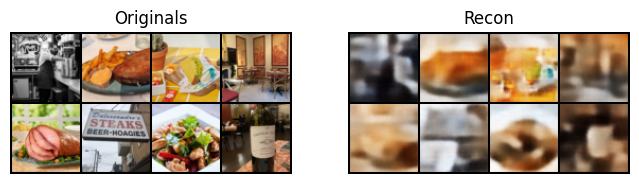

In [ ]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

model.eval()
with torch.no_grad():
    imgs = next(iter(loader))[:8].to(device)
    recon, _, _ = model(imgs)

grid_orig  = make_grid(imgs.cpu(),  nrow=4, normalize=True)
grid_recon = make_grid(recon.cpu(), nrow=4, normalize=True)

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(8,4))
ax1.imshow(grid_orig.permute(1,2,0)); ax1.set_title("Originals");  ax1.axis('off')
ax2.imshow(grid_recon.permute(1,2,0));ax2.set_title("Recon");      ax2.axis('off')
plt.show()


In [ ]:

os.makedirs('/content/vae_models', exist_ok=True)
torch.save(model.state_dict(),    '/content/vae_models/vae_full.pth')
torch.save(model.dec.state_dict(),'/content/vae_models/decoder.pth')
print(" Saved VAE and decoder to /content/vae_models/")


 Saved VAE and decoder to /content/vae_models/


### Part 2

Diffusion in latent space.

In [ ]:
# Install & imports
!pip install -q diffusers accelerate

import torch, os
from diffusers import DDPMPipeline, DDPMScheduler, UNet2DModel
from torchvision.utils import save_image, make_grid
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [ ]:
import os
print("Files in /content/vae_models/:")
print(os.listdir('/content/vae_models'))


Files in /content/vae_models/:
['decoder.pth', 'vae_full.pth']


In [ ]:
# Re‑define ConvVAE decoder only
import torch.nn as nn
class ConvVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64,  32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(32,   3, 4, 2, 1), nn.Sigmoid()
        )
    def decode(self, z):
        return self.dec(z)

# Load decoder weights
vae = ConvVAE(latent_dim=128).to(device)
vae.dec.load_state_dict(torch.load('/content/vae_models/decoder.pth', map_location=device))
vae.dec.eval()

Sequential(
  (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (1): ReLU()
  (2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (3): ReLU()
  (4): ConvTranspose2d(32, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (5): Sigmoid()
)

In [ ]:
from diffusers import UNet2DModel

latent_unet = UNet2DModel(
    sample_size=8,          # spatial size of latents
    in_channels=128,        # same as VAE latent channels
    out_channels=128,       # predicting noise
    block_out_channels=(256, 256),  # 2 levels
    down_block_types=("DownBlock2D", "DownBlock2D"),
    up_block_types=("UpBlock2D", "UpBlock2D"),
    layers_per_block=2
).to(device)

In [ ]:
from diffusers import DDPMScheduler
from tqdm import tqdm
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

# 1. Initialize scheduler (1000 steps)
scheduler = DDPMScheduler(num_train_timesteps=1000)
scheduler.set_timesteps(1000)

# 2. Start from Gaussian noise in latent space
latents = torch.randn((5, 128, 8, 8)).to(device)  # 5 samples

# 3. Run DDPM reverse diffusion loop
for t in tqdm(scheduler.timesteps):
    with torch.no_grad():
        noise_pred = latent_unet(latents, t).sample
        latents = scheduler.step(noise_pred, t, latents).prev_sample

100%|██████████| 1000/1000 [00:17<00:00, 57.31it/s]


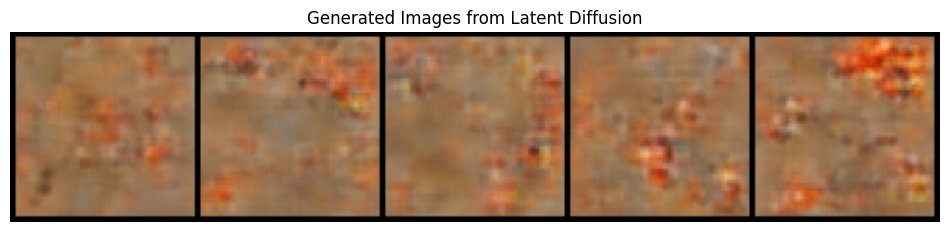

In [ ]:
# 4. Decode latents using your trained VAE
with torch.no_grad():
    decoded_images = vae.decode(latents).clamp(0, 1)  # [5, 3, 64, 64]

# 5. Visualize the results in a grid
grid = make_grid(decoded_images.cpu(), nrow=5, normalize=True)
plt.figure(figsize=(12, 3))
plt.imshow(grid.permute(1, 2, 0))
plt.axis('off')
plt.title("Generated Images from Latent Diffusion")
plt.show()

## Text-to-Image Diffusion Model

In [ ]:
photos_dir = "photos"
json_path = "photos.json"
output_dir = "processed_yelp_images_strict_balanced"
os.makedirs(output_dir, exist_ok=True)

# Label settings
accepted_labels = {"food", "drink", "inside", "outside", "menu"}
original_label_counts = defaultdict(int)
balanced_label_counts = defaultdict(int)
selected_counts = defaultdict(int)

# First pass: count all labels
with open(json_path, 'r', encoding='utf-8') as f:
    for line in f:
        try:
            item = json.loads(line)
            label = item.get("label")
            if label in accepted_labels:
                original_label_counts[label] += 1
        except json.JSONDecodeError:
            continue

# Determine minimum count to balance
label_limit = min(original_label_counts[label] for label in accepted_labels)

print(f"Balancing to {label_limit} images per class.")
print("Label counts before balancing:")
for label in accepted_labels:
    print(f"{label}: {original_label_counts[label]}")

# Second pass: copy up to label_limit images per class
with open(json_path, 'r', encoding='utf-8') as f:
    for line in f:
        try:
            item = json.loads(line)
            label = item.get("label")
            photo_id = item.get("photo_id")

            if label not in accepted_labels:
                continue
            if selected_counts[label] >= label_limit:
                continue

            # Search for matching image file (any extension)
            for ext in [".jpg", ".jpeg", ".png"]:
                src_path = os.path.join(photos_dir, photo_id + ext)
                if os.path.isfile(src_path):
                    dest_path = os.path.join(output_dir, f"{label}_{photo_id}{ext}")
                    shutil.copyfile(src_path, dest_path)
                    selected_counts[label] += 1
                    break

        except json.JSONDecodeError:
            continue

# Print after balancing
print("\nLabel counts after balancing:")
for label in accepted_labels:
    print(f"{label}: {selected_counts[label]}")

Balancing to 1678 images per class.
Label counts before balancing:
inside: 56031
food: 108152
outside: 18569
menu: 1678
drink: 15670

Label counts after balancing:
inside: 1678
food: 1678
outside: 1678
menu: 1678
drink: 1678


### Label Mapping

In [ ]:
captions = []
with open(json_path, "r", encoding="utf-8") as f:
    for line in f:
        try:
            item = json.loads(line)
            label = item.get("label")
            photo_id = item.get("photo_id")
            caption = item.get("caption", "").strip()

            if (
                label in accepted_labels and
                caption and
                any(os.path.exists(os.path.join(output_dir, f"{label}_{photo_id}{ext}")) for ext in [".jpg", ".jpeg", ".png"])
            ):
                captions.append({
                    "photo_id": photo_id,
                    "label": label,
                    "caption": caption
                })
        except json.JSONDecodeError:
            continue

# Save as CSV
caption_df = pd.DataFrame(captions)
caption_df.to_csv("caption_label_mapping.csv", index=False)
caption_df.head()


,photo_id,label,caption
0,zsvj7vloL4L5jhYyPIuVwg,inside,Nice rock artwork everywhere and craploads of ...
1,vkr8T0scuJmGVvN2HJelEA,drink,oyster shooter
2,pve7D6NUrafHW3EAORubyw,food,Shrimp scampi
3,3ROd5PAQ_0OkmoKWVO06ag,inside,Inside reception
4,foJzmWwl8WlC3xi-QQDRgg,outside,Small portion of the back patio


In [ ]:
# Label-specific prompt templates
label_prompts = {
    "food": "A close-up photo of delicious food served at a restaurant.",
    "drink": "A high-quality image of a refreshing drink at a restaurant.",
    "inside": "An interior view of a restaurant with people and tables.",
    "outside": "An outdoor shot of a restaurant building and entrance.",
    "menu": "A well-lit photo of a restaurant menu showing food items."
}

# Create new column with prompts
caption_df["prompt"] = caption_df["label"].map(label_prompts)
caption_df.head()

,photo_id,label,caption,prompt
0,zsvj7vloL4L5jhYyPIuVwg,inside,Nice rock artwork everywhere and craploads of ...,An interior view of a restaurant with people a...
1,vkr8T0scuJmGVvN2HJelEA,drink,oyster shooter,A high-quality image of a refreshing drink at ...
2,pve7D6NUrafHW3EAORubyw,food,Shrimp scampi,A close-up photo of delicious food served at a...
3,3ROd5PAQ_0OkmoKWVO06ag,inside,Inside reception,An interior view of a restaurant with people a...
4,foJzmWwl8WlC3xi-QQDRgg,outside,Small portion of the back patio,An outdoor shot of a restaurant building and e...


In [ ]:
caption_df.to_csv("caption_prompt_mapping.csv", index=False)
print("Saved to caption_prompt_mapping.csv")

Saved to caption_prompt_mapping.csv


### Dataset

In [ ]:
import pandas as pd
import os

df = pd.read_csv("caption_prompt_mapping.csv")

# Add full image paths based on label and photo_id
def get_image_path(row):
    base = f"{row['label']}_{row['photo_id']}"
    for ext in [".jpg", ".jpeg", ".png"]:
        path = os.path.join("processed_yelp_images_strict_balanced", base + ext)
        if os.path.exists(path):
            return path
    return None

df["image_path"] = df.apply(get_image_path, axis=1)
df = df[df["image_path"].notnull()].reset_index(drop=True)
df.head()

,photo_id,label,caption,prompt,image_path
0,zsvj7vloL4L5jhYyPIuVwg,inside,Nice rock artwork everywhere and craploads of ...,An interior view of a restaurant with people a...,processed_yelp_images_strict_balanced\inside_z...
1,vkr8T0scuJmGVvN2HJelEA,drink,oyster shooter,A high-quality image of a refreshing drink at ...,processed_yelp_images_strict_balanced\drink_vk...
2,pve7D6NUrafHW3EAORubyw,food,Shrimp scampi,A close-up photo of delicious food served at a...,processed_yelp_images_strict_balanced\food_pve...
3,3ROd5PAQ_0OkmoKWVO06ag,inside,Inside reception,An interior view of a restaurant with people a...,processed_yelp_images_strict_balanced\inside_3...
4,foJzmWwl8WlC3xi-QQDRgg,outside,Small portion of the back patio,An outdoor shot of a restaurant building and e...,processed_yelp_images_strict_balanced\outside_...


In [ ]:
from diffusers import StableDiffusionPipeline
from peft import get_peft_model, LoraConfig, TaskType
from accelerate import Accelerator
import torch

accelerator = Accelerator()
device = accelerator.device

pipe = StableDiffusionPipeline.from_pretrained(
    "stabilityai/sd-turbo",
    torch_dtype=torch.float32,  # safer for torch <2.6
    safety_checker=None
).to(device)

pipe.unet.requires_grad_(False)
pipe.vae.requires_grad_(False)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.FEATURE_EXTRACTION
)

pipe.text_encoder = get_peft_model(pipe.text_encoder, lora_config)
pipe.text_encoder.print_trainable_parameters()

Loading pipeline components...: 100%|████████████████████████████████████████████████████| 5/5 [00:00<00:00,  5.96it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


trainable params: 753,664 || all params: 341,141,504 || trainable%: 0.2209


In [ ]:
from transformers import CLIPTokenizer
from torch.utils.data import DataLoader
from torchvision import transforms
from torch.utils.data import Dataset
from PIL import Image

tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")

class YelpText2ImageDataset(Dataset):
    def __init__(self, dataframe, tokenizer, image_size=256):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3)
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        image = self.transform(image)

        text = self.tokenizer(
            row["caption"],  # ← use actual caption text
            padding="max_length",
            max_length=77,
            truncation=True,
            return_tensors="pt"
        )

        return {
            "pixel_values": image,
            "input_ids": text.input_ids.squeeze(0),
            "attention_mask": text.attention_mask.squeeze(0),
            "label": row["label"]
        }

dataset = YelpText2ImageDataset(df, tokenizer)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

### Model

Single epoch

In [ ]:
from tqdm import tqdm
import torch
import torch.nn.functional as F

pipe.unet.train()
pipe.text_encoder.train()

# Optimizer for both UNet and text encoder (you can adjust if you want only text_encoder)
optimizer = torch.optim.AdamW(
    list(pipe.unet.parameters()) + list(pipe.text_encoder.parameters()),
    lr=1e-5
)

for step, batch in enumerate(tqdm(dataloader, desc="Training", dynamic_ncols=True, leave=False)):
    pixel_values = batch["pixel_values"].to(device)
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)

    # Encode images into latent space
    latents = pipe.vae.encode(pixel_values).latent_dist.sample()
    latents = latents * 0.18215

    # Sample random timesteps
    timesteps = torch.randint(
        0, pipe.scheduler.config.num_train_timesteps,
        (latents.shape[0],), device=device
    ).long()

    # Add noise
    noise = torch.randn_like(latents)
    noisy_latents = pipe.scheduler.add_noise(latents, noise, timesteps)

    # Text encoder (with PEFT adapter)
    encoder_hidden_states = pipe.text_encoder.base_model(
        input_ids=input_ids,
        attention_mask=attention_mask
    ).last_hidden_state

    # Predict noise with UNet
    noise_pred = pipe.unet(
        noisy_latents, timesteps, encoder_hidden_states=encoder_hidden_states
    ).sample

    # MSE Loss
    loss = F.mse_loss(noise_pred, noise)

    # Backpropagation
    optimizer.zero_grad()
    accelerator.backward(loss)
    optimizer.step()

    if step % 100 == 0:
        print(f"\rStep {step}: Loss = {loss.item():.4f}", end="", flush=True)

Training:   0%|                                                                               | 0/2038 [00:00<?, ?it/s]

Step 0: Loss = 0.3269

Training:   5%|███▍                                                                 | 100/2038 [00:31<09:59,  3.23it/s]

Step 100: Loss = 0.2235

Training:  10%|██████▊                                                              | 200/2038 [01:00<08:46,  3.49it/s]

...

Step 1800: Loss = 0.2473

Training:  93%|███████████████████████████████████████████████████████████████▍    | 1900/2038 [09:05<00:37,  3.68it/s]

Step 1900: Loss = 0.2007

Training:  98%|██████████████████████████████████████████████████████████████████▋ | 2000/2038 [09:33<00:10,  3.74it/s]

Step 2000: Loss = 0.2865

Multiple epochs

In [ ]:
import os
import torch
from tqdm import tqdm
import torch.nn.functional as F

# Training hyperparameters
epochs = 5
lr = 1e-5
save_steps = 500
save_dir = "checkpoints"
os.makedirs(save_dir, exist_ok=True)

In [ ]:
# Set model components to train mode
pipe.unet.train()
pipe.text_encoder.train()

# Optimizer: UNet + text encoder
optimizer = torch.optim.AdamW(
    list(pipe.unet.parameters()) + list(pipe.text_encoder.parameters()),
    lr=lr
)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1000, gamma=0.95)

In [ ]:
global_step = 0

for epoch in range(epochs):
    print(f"\nEpoch {epoch + 1}/{epochs}")

    for step, batch in enumerate(tqdm(dataloader, desc="Training", dynamic_ncols=True, leave=False)):
        pipe.unet.train()
        pipe.text_encoder.train()

        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        latents = pipe.vae.encode(pixel_values).latent_dist.sample() * 0.18215

        timesteps = torch.randint(
            0, pipe.scheduler.config.num_train_timesteps,
            (latents.shape[0],), device=device
        ).long()
        noise = torch.randn_like(latents)
        noisy_latents = pipe.scheduler.add_noise(latents, noise, timesteps)

        encoder_hidden_states = pipe.text_encoder.base_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).last_hidden_state

        noise_pred = pipe.unet(
            noisy_latents, timesteps, encoder_hidden_states=encoder_hidden_states
        ).sample

        loss = F.mse_loss(noise_pred, noise)

        optimizer.zero_grad()
        accelerator.backward(loss)
        optimizer.step()
        scheduler.step()

        if global_step % 1000 == 0:
            print(f"\rEpoch {epoch + 1}, Step {global_step}: Loss = {loss.item():.4f}", end="", flush=True)

        # Save checkpoint only
        if global_step % save_steps == 0 and global_step != 0:
            checkpoint_path = os.path.join(save_dir, f"checkpoint_step{global_step}")
            pipe.save_pretrained(checkpoint_path)
            print(f"\nSaved checkpoint at step {global_step} to {checkpoint_path}")

        global_step += 1


In [ ]:
from torchvision import transforms as T
from diffusers import EulerDiscreteScheduler


pipe.unet.eval()
pipe.text_encoder.eval()
pipe.vae.eval()

eval_dir = os.path.join(save_dir, f"eval_samples_step{global_step}")
os.makedirs(eval_dir, exist_ok=True)

prompts = {
    "food": "A close-up photo of delicious food served at a restaurant.",
    "drink": "A high-quality image of a refreshing drink at a restaurant.",
    "inside": "An interior view of a restaurant with people and tables.",
    "outside": "An outdoor shot of a restaurant building and entrance.",
    "menu": "A well-lit photo of a restaurant menu showing food items."
}

transform = T.ToPILImage()
num_inference_steps = 50

with torch.no_grad():
    for label, prompt in prompts.items():
        # Re-init scheduler every time to reset internal state
        pipe.scheduler = EulerDiscreteScheduler.from_config(pipe.scheduler.config)
        pipe.scheduler.set_timesteps(num_inference_steps)
        timesteps = pipe.scheduler.timesteps

        # Tokenize
        inputs = tokenizer(prompt, return_tensors="pt").to(device)
        prompt_embeds = pipe.text_encoder.base_model(
            input_ids=inputs.input_ids,
            attention_mask=inputs.attention_mask
        ).last_hidden_state

        # Latent noise
        latents = torch.randn((1, pipe.unet.in_channels, 64, 64), device=device)
        latents = latents * pipe.scheduler.init_noise_sigma

        # Denoising loop
        for t in timesteps[:-1]:
            latent_model_input = pipe.scheduler.scale_model_input(latents, t)
            noise_pred = pipe.unet(latent_model_input, t, encoder_hidden_states=prompt_embeds).sample
            latents = pipe.scheduler.step(noise_pred, t, latents).prev_sample

        # Decode
        image = pipe.vae.decode(latents / 0.18215).sample
        image = (image / 2 + 0.5).clamp(0, 1)
        image_pil = transform(image.squeeze().cpu())
        image_pil.save(os.path.join(eval_dir, f"{label}.jpg"))
        print(f"Saved {label} sample.")


Saved food sample.
Saved drink sample.
Saved inside sample.
Saved outside sample.
Saved menu sample.


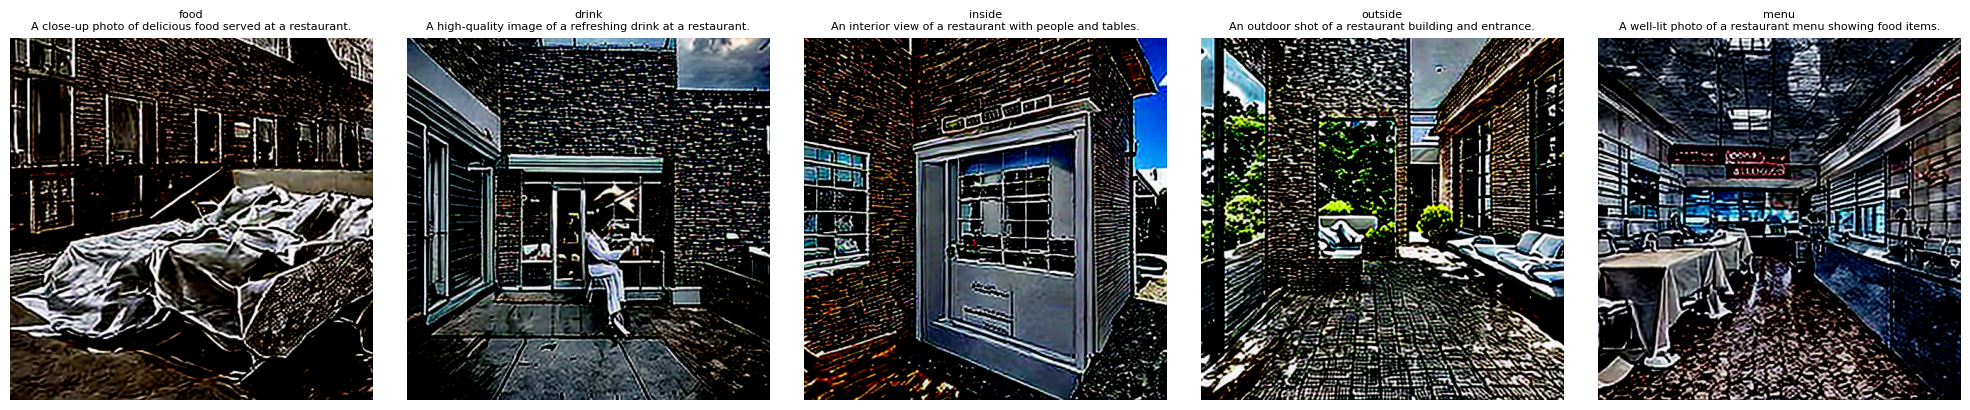

In [ ]:
import torch
from transformers import CLIPTokenizer
from diffusers import EulerDiscreteScheduler
import matplotlib.pyplot as plt

# Use the tokenizer (already available from pipeline)
tokenizer = pipe.tokenizer

# Prompts per label
prompts = {
    "food": "A close-up photo of delicious food served at a restaurant.",
    "drink": "A high-quality image of a refreshing drink at a restaurant.",
    "inside": "An interior view of a restaurant with people and tables.",
    "outside": "An outdoor shot of a restaurant building and entrance.",
    "menu": "A well-lit photo of a restaurant menu showing food items."
}

# Setup plot
fig, axs = plt.subplots(1, len(prompts), figsize=(20, 4))

# Disable grad
pipe.text_encoder.eval()
pipe.unet.eval()
pipe.vae.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with torch.no_grad():
    for i, (label, prompt) in enumerate(prompts.items()):
        # Tokenize and encode prompt
        tokens = tokenizer(prompt, return_tensors="pt", padding="max_length", truncation=True, max_length=77)
        input_ids = tokens.input_ids.to(device)
        attention_mask = tokens.attention_mask.to(device)

        prompt_embeds = pipe.text_encoder.base_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).last_hidden_state

        # Reset scheduler
        pipe.scheduler = EulerDiscreteScheduler.from_config(pipe.scheduler.config)
        pipe.scheduler.set_timesteps(50, device=device)

        # Generate initial latents
        latents = torch.randn((1, pipe.unet.in_channels, pipe.unet.sample_size, pipe.unet.sample_size)).to(device)
        latents = latents * pipe.scheduler.init_noise_sigma

        # Denoising loop
        for t in pipe.scheduler.timesteps:
            latent_model_input = pipe.scheduler.scale_model_input(latents, t)
            noise_pred = pipe.unet(latent_model_input, t, encoder_hidden_states=prompt_embeds).sample
            latents = pipe.scheduler.step(noise_pred, t, latents).prev_sample

        # Decode latents
        image = pipe.vae.decode(latents / 0.18215).sample[0]
        image = image.clamp(0, 1).cpu().permute(1, 2, 0).numpy()

        axs[i].imshow(image)
        axs[i].axis("off")
        axs[i].set_title(f"{label}\n{prompt}", fontsize=8)

plt.tight_layout()
plt.show()


### Part 2

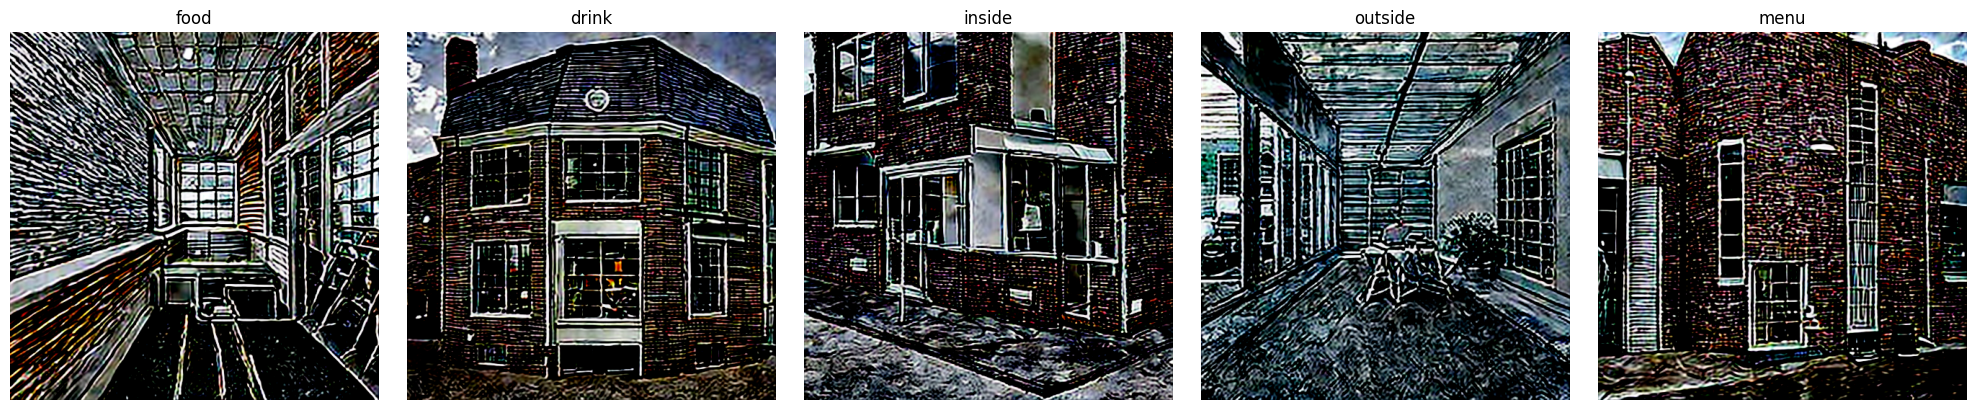

In [ ]:
from diffusers import EulerDiscreteScheduler
import matplotlib.pyplot as plt
import os

# Define label prompts
prompts = {
    "food": "A close-up photo of delicious food served at a restaurant.",
    "drink": "A high-quality image of a refreshing drink at a restaurant.",
    "inside": "An interior view of a restaurant with people and tables.",
    "outside": "An outdoor shot of a restaurant building and entrance.",
    "menu": "A well-lit photo of a restaurant menu showing food items."
}

# Image saving directory
eval_dir = os.path.join(save_dir, f"eval_samples_step{global_step}")
os.makedirs(eval_dir, exist_ok=True)

# Display and generate images
fig, axs = plt.subplots(1, len(prompts), figsize=(20, 4))

for i, (label, prompt) in enumerate(prompts.items()):
    # Reset scheduler state
    pipe.scheduler = EulerDiscreteScheduler.from_config(pipe.scheduler.config)
    pipe.scheduler.set_timesteps(50)

    # Manual sampling since pipe(prompt=...) causes conflict with LoRA encoder
    text_input = tokenizer(prompt, return_tensors="pt").input_ids.to(device)
    prompt_embeds = pipe.text_encoder.base_model(input_ids=text_input).last_hidden_state

    latents = torch.randn((1, pipe.unet.in_channels, 64, 64)).to(device)
    latents = latents * pipe.scheduler.init_noise_sigma
    timesteps = pipe.scheduler.timesteps

    with torch.no_grad():
        for t in timesteps[:-1]:
            latent_model_input = pipe.scheduler.scale_model_input(latents, t)
            noise_pred = pipe.unet(latent_model_input, t, encoder_hidden_states=prompt_embeds).sample
            latents = pipe.scheduler.step(noise_pred, t, latents).prev_sample

        image = pipe.vae.decode(latents / 0.18215).sample
        image = image.clamp(0, 1).cpu().permute(0, 2, 3, 1).squeeze().numpy()

    # Save & show image
    image_path = os.path.join(eval_dir, f"{label}.png")
    plt.imsave(image_path, image)
    axs[i].imshow(image)
    axs[i].axis("off")
    axs[i].set_title(label)

plt.tight_layout()
plt.show()

In [ ]:
from torchvision.models.inception import inception_v3
import torchvision.transforms as T
from torchvision.datasets.folder import default_loader
from torch.nn.functional import adaptive_avg_pool2d

def load_inception_model():
    model = inception_v3(pretrained=True, transform_input=False)
    model.fc = torch.nn.Identity()  # remove final classification layer
    model.eval()
    return model.to(device)

def preprocess_images(images, resize_to=299):
    transform = T.Compose([
        T.Resize((resize_to, resize_to)),
        T.ToTensor(),
        T.Normalize([0.5]*3, [0.5]*3)
    ])
    if isinstance(images[0], str):  # path list
        return torch.stack([transform(default_loader(img)).to(device) for img in images])
    else:  # already PIL
        return torch.stack([transform(img).to(device) for img in images])


In [ ]:
from PIL import Image
import glob
import random

# Paths
gen_dir = os.path.join(save_dir, f"eval_samples_step{global_step}")
real_dir = "processed_yelp_images_strict_balanced"

# Load generated images (1 per label)
generated_images = [Image.open(os.path.join(gen_dir, f"{label}.png")).convert("RGB") for label in prompts.keys()]

# Load real images (1 per label)
real_images = []
for label in prompts.keys():
    candidates = glob.glob(os.path.join(real_dir, f"{label}_*.jpg"))
    if not candidates:  # fallback for .jpeg/.png
        candidates = glob.glob(os.path.join(real_dir, f"{label}_*.jpeg")) + glob.glob(os.path.join(real_dir, f"{label}_*.png"))
    real_images.append(Image.open(random.choice(candidates)).convert("RGB"))


In [ ]:
import numpy as np
from scipy.linalg import sqrtm

# Load model
inception_model = load_inception_model()

# Prepare tensors
gen_tensor = preprocess_images(generated_images)
real_tensor = preprocess_images(real_images)

# Extract features
with torch.no_grad():
    gen_features = inception_model(gen_tensor).cpu().numpy()
    real_features = inception_model(real_tensor).cpu().numpy()

# Inception Score (simplified)
def inception_score(feats):
    p_yx = torch.nn.functional.softmax(torch.tensor(feats), dim=1)
    p_y = p_yx.mean(0)
    kl_div = p_yx * (p_yx.log() - p_y.log())
    return torch.exp(kl_div.sum(1).mean()).item()

# FID
def calculate_fid(mu1, sigma1, mu2, sigma2):
    covmean = sqrtm(sigma1 @ sigma2)
    if np.iscomplexobj(covmean): covmean = covmean.real
    fid = np.sum((mu1 - mu2)**2) + np.trace(sigma1 + sigma2 - 2 * covmean)
    return fid

# Compute means and covariances
mu_gen, sigma_gen = gen_features.mean(0), np.cov(gen_features, rowvar=False)
mu_real, sigma_real = real_features.mean(0), np.cov(real_features, rowvar=False)

# Final metrics
IS = inception_score(gen_features)
FID = calculate_fid(mu_gen, sigma_gen, mu_real, sigma_real)

print(f"\nInception Score: {IS:.4f}")
print(f"FID Score: {FID:.4f}")



Inception Score: 1.0489
FID Score: 457.8513


## Evaluation

## Prompts Used

1. DDIM generate 5 + images Save and organise the generated image for evaluation
2. ValueError: Expecting image as torch.Tensor with  dtype=torch.uint8
3. Given a VAE trained on the Yelp dataset with saved encoder and decoder models, please perform diffusion in the latent space, decode the resulting samples, and generate and save five high-quality images.
4. what error is this: 100% 1000/1000 [00:10<00:00, 71.49it/s]
    
    KeyError                                  Traceback (most recent call last)
    /usr/local/lib/python3.11/dist-packages/PIL/Image.py in fromarray(obj, mode)
      3307         try:
    -> 3308             mode, rawmode = _fromarray_typemap[typekey]
      3309         except KeyError as e:

    KeyError: ((1, 1, 128), '|u1')

    The above exception was the direct cause of the following exception:

    TypeError                                 Traceback (most recent call last)
    6 frames
    /usr/local/lib/python3.11/dist-packages/PIL/Image.py in fromarray(obj, mode)
      3310             typekey_shape, typestr = typekey
      3311             msg = f"Cannot handle this data type: {typekey_shape}, {typestr}"
    -> 3312             raise TypeError(msg) from e
      3313     else:
      3314         deprecate("'mode' parameter", 13)

    TypeError: Cannot handle this data type: (1, 1, 128), |u1 still
5. Fine tune Glide like text 2 image diffusion model with the data i have.
6. RuntimeError: Failed to import diffusers.models.unets.unet_2d_condition because of the following error (look up to see its traceback):
No module named 'diffusers.models.unets
7. Perform the given task on the code as continuation of the given code
8. Use custom IS and FID
9. give me model for ddpm architecture queries . Walk me through the steps
10. give me steps to save the model checkpoints and the logs.
11. How to build DDIM Module and implement it to train on yelp photodatasets.
12. Please helps to train it and save checkpoints and savlogs
13. How to fine-tune a DDPM model on the Yelp dataset using diffusers and adjust hyperparameters like noise schedule and learning rate.
14. Help me generate 5+ images using the trained DDPM and save the images, model checkpoints, and log file properly.
15. How to preprocess the Yelp text dataset to use it with a VAE or autoencoder? (Include tokenization, padding, and formatting steps
16. How do I save the encoder and decoder models properly for use in the diffusion process later?


